### Step 1: Load the Libraies and Data

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from numpy.linalg import lstsq
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.layers import LSTM, Dense, Dropout, GRU, Conv1D, SimpleRNN
from keras.callbacks import EarlyStopping 

In [41]:
# extracting the data 
data = pd.read_csv(".\datasets\T1.csv")
data.head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\aalma\AppData\Local\Temp\ipykernel_4996\1502131984.py:2: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv(".\datasets\T1.csv")


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


## Section 1: Data Description

In [42]:
# data decsription (we can see that the data is not normalized) 
data.describe()

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,50530.000000,50530.000000,50530.000000,50530.000000
mean,1307.684332,7.557952,1492.175463,123.687559
std,1312.459242,4.227166,1368.018238,93.443736
min,-2.471405,0.000000,0.000000,0.000000
25%,50.677890,4.201395,161.328167,49.315437
50%,825.838074,7.104594,1063.776283,73.712978
75%,2482.507568,10.300020,2964.972462,201.696720
max,3618.732910,25.206011,3600.000000,359.997589


In [43]:
# data information (Data types, missing values, etc.)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  object 
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.9+ MB


In [44]:
data.isnull().sum()

Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64

In [45]:
# Spliting the date time in year, month, days, hours and minutes
data['Year']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[0])
data['Month']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[1])
data['Day']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[2])
data['Time_Hours']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[3])
data['Time_Minutes']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[4])
data.head(5)

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40


In [46]:
# convert a datetime to a timestamp
data['Date/Time'] = pd.to_datetime(data['Date/Time'], format='%d %m %Y %H:%M')
data


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40
...,...,...,...,...,...,...,...,...,...,...
50525,2018-12-31 23:10:00,2963.980957,11.404030,3397.190793,80.502724,2018,12,31,23,10
50526,2018-12-31 23:20:00,1684.353027,7.332648,1173.055771,84.062599,2018,12,31,23,20
50527,2018-12-31 23:30:00,2201.106934,8.435358,1788.284755,84.742500,2018,12,31,23,30
50528,2018-12-31 23:40:00,2515.694092,9.421366,2418.382503,84.297913,2018,12,31,23,40


In [47]:
# Filter data for the selected month and reset index
x = [12]  # Convert x to a list
data1 = data.loc[data['Month'].isin(x)]  # Selecting the data for the month x
data1 = data1.reset_index(drop=True)  # Resetting the index
data1 = data1.dropna()  # Dropping the missing values

data_wind = data1[['LV ActivePower (kW)', 'Theoretical_Power_Curve (KWh)']]

# Separate input feature and target
features = data_wind[['LV ActivePower (kW)', 'Theoretical_Power_Curve (KWh)']]
target = data_wind['LV ActivePower (kW)']


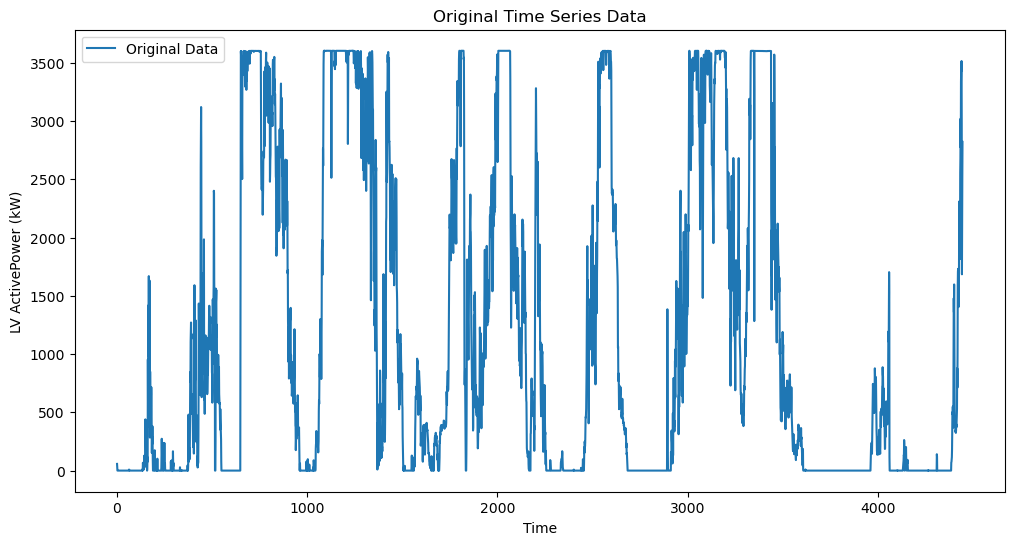

In [48]:
# Plot the original time series data
plt.figure(figsize=(12, 6))
plt.plot(data_wind.index, data_wind['LV ActivePower (kW)'].values, label='Original Data')
plt.title('Original Time Series Data')
plt.xlabel('Time')
plt.ylabel('LV ActivePower (kW)')
plt.legend()
plt.show()

In [49]:
# find the total number of rows
total_rows = data_wind.count()
total_rows

LV ActivePower (kW)              4447
Theoretical_Power_Curve (KWh)    4447
dtype: int64

In [50]:
features.head()

,LV ActivePower (kW),Theoretical_Power_Curve (KWh)
0,57.407021,681.780444
1,27.440510,586.656800
2,0.364866,378.397651
3,0.000000,245.089872
4,0.000000,268.621965


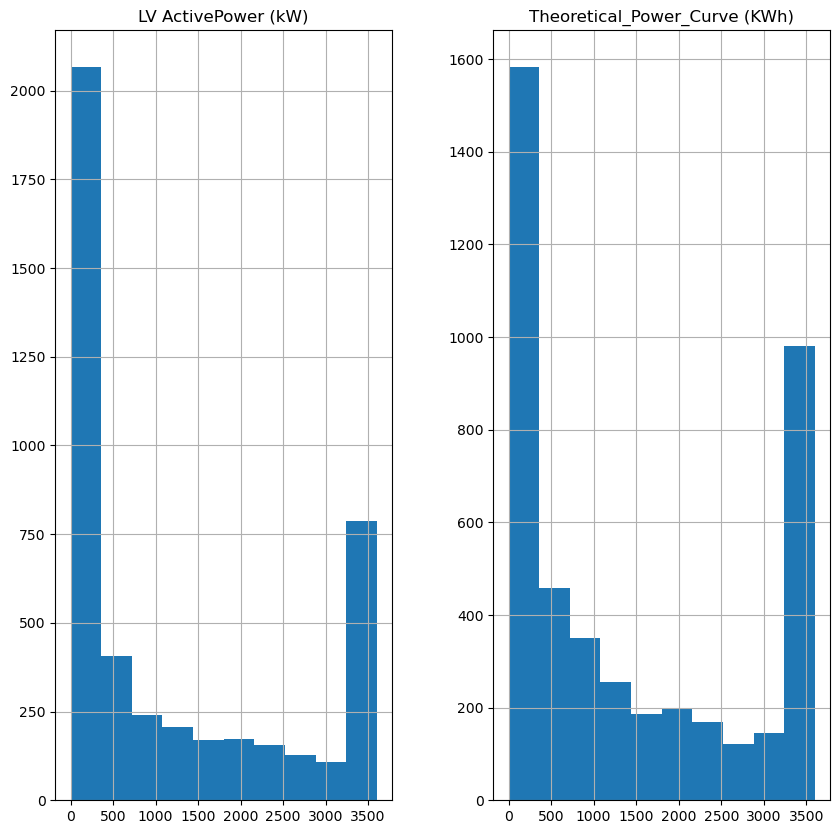

In [51]:
# plot the distribution of the features
features.hist(figsize=(10, 10))
plt.show()


In [52]:
scaler_features = MinMaxScaler()

# Fit the scaler on the features data
scaler_features.fit(features[['LV ActivePower (kW)', 'Theoretical_Power_Curve (KWh)']])
# Transform the data with the adjusted scaler
features_scaled = pd.DataFrame(scaler_features.transform(features[['LV ActivePower (kW)', 'Theoretical_Power_Curve (KWh)']]),
                               columns=['LV ActivePower (kW)', 'Theoretical_Power_Curve (KWh)'])

In [53]:
features_scaled.head()

,LV ActivePower (kW),Theoretical_Power_Curve (KWh)
0,0.016228,0.189383
1,0.007913,0.162960
2,0.000400,0.105110
3,0.000299,0.068081
4,0.000299,0.074617


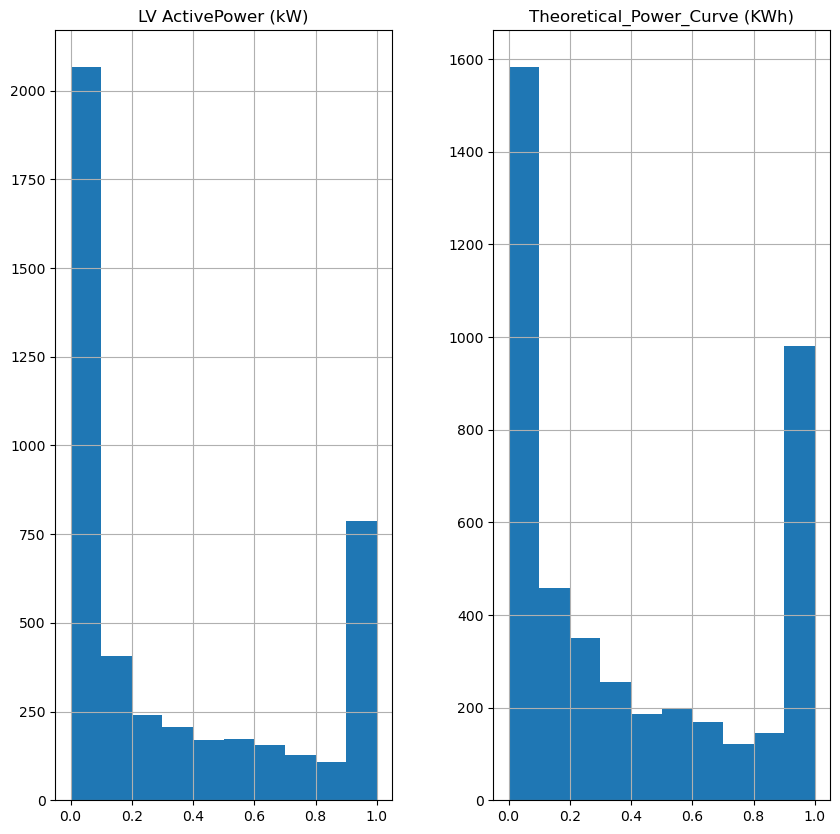

In [54]:
# plot the distribution of the features
features_scaled.hist(figsize=(10, 10))
plt.show()

In [55]:
target_scaler = MinMaxScaler()
target_scaled = pd.DataFrame(target_scaler.fit_transform(target.values.reshape(-1, 1)).flatten())

In [56]:
target_scaled

,0
0,0.016228
1,0.007913
2,0.000400
3,0.000299
4,0.000299
...,...
4442,0.822745
4443,0.467674
4444,0.611063
4445,0.698354


In [57]:
from PyEMD import EMD, EEMD, CEEMDAN
import ewtpy

# Decompose each input feature and target using CEEMDAN
def decompose_with_ceemdan(series, noise_seed=12345):
    emd = CEEMDAN(epsilon=0.05, max_imf=8)
    emd.noise_seed(noise_seed)
    return pd.DataFrame(emd.emd(series.values)).T

# Decompose features and target
decomposed_features = {col: decompose_with_ceemdan(features_scaled[col]) for col in features.columns}
decomposed_target = decompose_with_ceemdan(target_scaled[0])

# Apply EWT to the first IMF of each feature and target
def apply_ewt_to_first_imf(imf):
    ewt_coeffs, _, _ = ewtpy.EWT1D(imf.values, N=3)
    denoised_imf = pd.DataFrame(ewt_coeffs).sum(axis=1)
    return denoised_imf

for col in decomposed_features:
    decomposed_features[col].iloc[:, 0] = apply_ewt_to_first_imf(decomposed_features[col].iloc[:, 0])
decomposed_target.iloc[:, 0] = apply_ewt_to_first_imf(decomposed_target.iloc[:, 0])

# Ensure all components have the same number of IMFs
min_imfs = min(min(df.shape[1] for df in decomposed_features.values()), decomposed_target.shape[1])
for col in decomposed_features:
    decomposed_features[col] = decomposed_features[col].iloc[:, :min_imfs]
decomposed_target = decomposed_target.iloc[:, :min_imfs]


In [58]:
decomposed_features['LV ActivePower (kW)']

,0,1,2,3,4,5,6,7,8,9
0,0.004071,-0.003790,-0.249889,0.374143,-0.136512,-0.057215,0.005544,0.062273,-0.230779,0.246151
1,-0.002574,-0.004087,-0.257319,0.382034,-0.137854,-0.057475,0.004963,0.062809,-0.230982,0.246153
2,-0.008488,-0.004121,-0.264641,0.389481,-0.138968,-0.057780,0.004379,0.063340,-0.231182,0.246156
3,-0.007169,-0.003900,-0.271812,0.396468,-0.139848,-0.058131,0.003792,0.063864,-0.231380,0.246159
4,-0.005821,-0.003471,-0.278771,0.402980,-0.140489,-0.058530,0.003202,0.064381,-0.231574,0.246162
...,...,...,...,...,...,...,...,...,...,...
4442,0.070168,0.002842,-0.048797,-0.049263,0.157896,0.272683,0.168830,-0.194414,-0.011748,0.440970
4443,-0.094048,-0.092159,-0.122390,-0.074732,0.162919,0.276474,0.170520,-0.193757,-0.011680,0.440964
4444,0.076505,-0.096465,-0.144895,-0.091145,0.165278,0.279782,0.172189,-0.193103,-0.011612,0.440958
4445,0.044190,-0.015420,-0.098655,-0.095431,0.164695,0.282591,0.173836,-0.192453,-0.011543,0.440953


In [59]:
decomposed_target

,0,1,2,3,4,5,6,7,8,9
0,0.004071,-0.003790,-0.249889,0.374143,-0.136512,-0.057215,0.005544,0.062273,-0.230779,0.246151
1,-0.002574,-0.004087,-0.257319,0.382034,-0.137854,-0.057475,0.004963,0.062809,-0.230982,0.246153
2,-0.008488,-0.004121,-0.264641,0.389481,-0.138968,-0.057780,0.004379,0.063340,-0.231182,0.246156
3,-0.007169,-0.003900,-0.271812,0.396468,-0.139848,-0.058131,0.003792,0.063864,-0.231380,0.246159
4,-0.005821,-0.003471,-0.278771,0.402980,-0.140489,-0.058530,0.003202,0.064381,-0.231574,0.246162
...,...,...,...,...,...,...,...,...,...,...
4442,0.070168,0.002842,-0.048797,-0.049263,0.157896,0.272683,0.168830,-0.194414,-0.011748,0.440970
4443,-0.094048,-0.092159,-0.122390,-0.074732,0.162919,0.276474,0.170520,-0.193757,-0.011680,0.440964
4444,0.076505,-0.096465,-0.144895,-0.091145,0.165278,0.279782,0.172189,-0.193103,-0.011612,0.440958
4445,0.044190,-0.015420,-0.098655,-0.095431,0.164695,0.282591,0.173836,-0.192453,-0.011543,0.440953


In [60]:
for col in decomposed_features:
    num_feature_imfs = decomposed_features[col].shape[1]
    for i in range(min_imfs):
        correlation = decomposed_features[col].iloc[:, i].corr(decomposed_target.iloc[:, i])
        print(f"Correlation between {col} IMF {i+1} and Target IMF {i+1}: {correlation}")

Correlation between LV ActivePower (kW) IMF 1 and Target IMF 1: 1.0
Correlation between LV ActivePower (kW) IMF 2 and Target IMF 2: 1.0
Correlation between LV ActivePower (kW) IMF 3 and Target IMF 3: 1.0
Correlation between LV ActivePower (kW) IMF 4 and Target IMF 4: 1.0
Correlation between LV ActivePower (kW) IMF 5 and Target IMF 5: 1.0
Correlation between LV ActivePower (kW) IMF 6 and Target IMF 6: 1.0
Correlation between LV ActivePower (kW) IMF 7 and Target IMF 7: 1.0
Correlation between LV ActivePower (kW) IMF 8 and Target IMF 8: 1.0
Correlation between LV ActivePower (kW) IMF 9 and Target IMF 9: 1.0
Correlation between LV ActivePower (kW) IMF 10 and Target IMF 10: 0.9999999999999998
Correlation between Theoretical_Power_Curve (KWh) IMF 1 and Target IMF 1: 0.15065582934586086
Correlation between Theoretical_Power_Curve (KWh) IMF 2 and Target IMF 2: 0.2860879953316743
Correlation between Theoretical_Power_Curve (KWh) IMF 3 and Target IMF 3: 0.25771091419315906
Correlation between Th

In [61]:
# Prepare for individual IMF training
num_imfs = decomposed_target.shape[1]  # Number of IMFs in the target

In [62]:
for i in range(decomposed_target.shape[1]):
    print(f"IMF {i+1}: Mean={decomposed_target.iloc[:, i].mean()}, Std={decomposed_target.iloc[:, i].std()}")

for col in decomposed_features:
    for i in range(decomposed_features[col].shape[1]):
        print(f"{col} IMF {i+1}: Mean={decomposed_features[col].iloc[:, i].mean()}, Std={decomposed_features[col].iloc[:, i].std()}")

IMF 1: Mean=0.002665077765728099, Std=0.08290543144760372
IMF 2: Mean=-0.00011607795834200984, Std=0.04626838828271211
IMF 3: Mean=-0.0017570687724639783, Std=0.08076195927196075
IMF 4: Mean=0.0029326720723214885, Std=0.08804662362054312
IMF 5: Mean=-0.0010426015687643947, Std=0.10361522808168495
IMF 6: Mean=-0.0032768592818080834, Std=0.14749932047753525
IMF 7: Mean=-0.01978394446387879, Std=0.2878334649737201
IMF 8: Mean=-0.047905643871815444, Std=0.22785375514400213
IMF 9: Mean=-0.007696243184929703, Std=0.09777459026752922
IMF 10: Mean=0.40281287920489484, Std=0.07427313183353923
LV ActivePower (kW) IMF 1: Mean=0.002665077765728099, Std=0.08290543144760372
LV ActivePower (kW) IMF 2: Mean=-0.00011607795834200984, Std=0.04626838828271211
LV ActivePower (kW) IMF 3: Mean=-0.0017570687724639783, Std=0.08076195927196075
LV ActivePower (kW) IMF 4: Mean=0.0029326720723214885, Std=0.08804662362054312
LV ActivePower (kW) IMF 5: Mean=-0.0010426015687643947, Std=0.10361522808168495
LV ActivePo

In [63]:
decomposed_target.head()

,0,1,2,3,4,5,6,7,8,9
0,0.004071,-0.003790,-0.249889,0.374143,-0.136512,-0.057215,0.005544,0.062273,-0.230779,0.246151
1,-0.002574,-0.004087,-0.257319,0.382034,-0.137854,-0.057475,0.004963,0.062809,-0.230982,0.246153
2,-0.008488,-0.004121,-0.264641,0.389481,-0.138968,-0.057780,0.004379,0.063340,-0.231182,0.246156
3,-0.007169,-0.003900,-0.271812,0.396468,-0.139848,-0.058131,0.003792,0.063864,-0.231380,0.246159
4,-0.005821,-0.003471,-0.278771,0.402980,-0.140489,-0.058530,0.003202,0.064381,-0.231574,0.246162


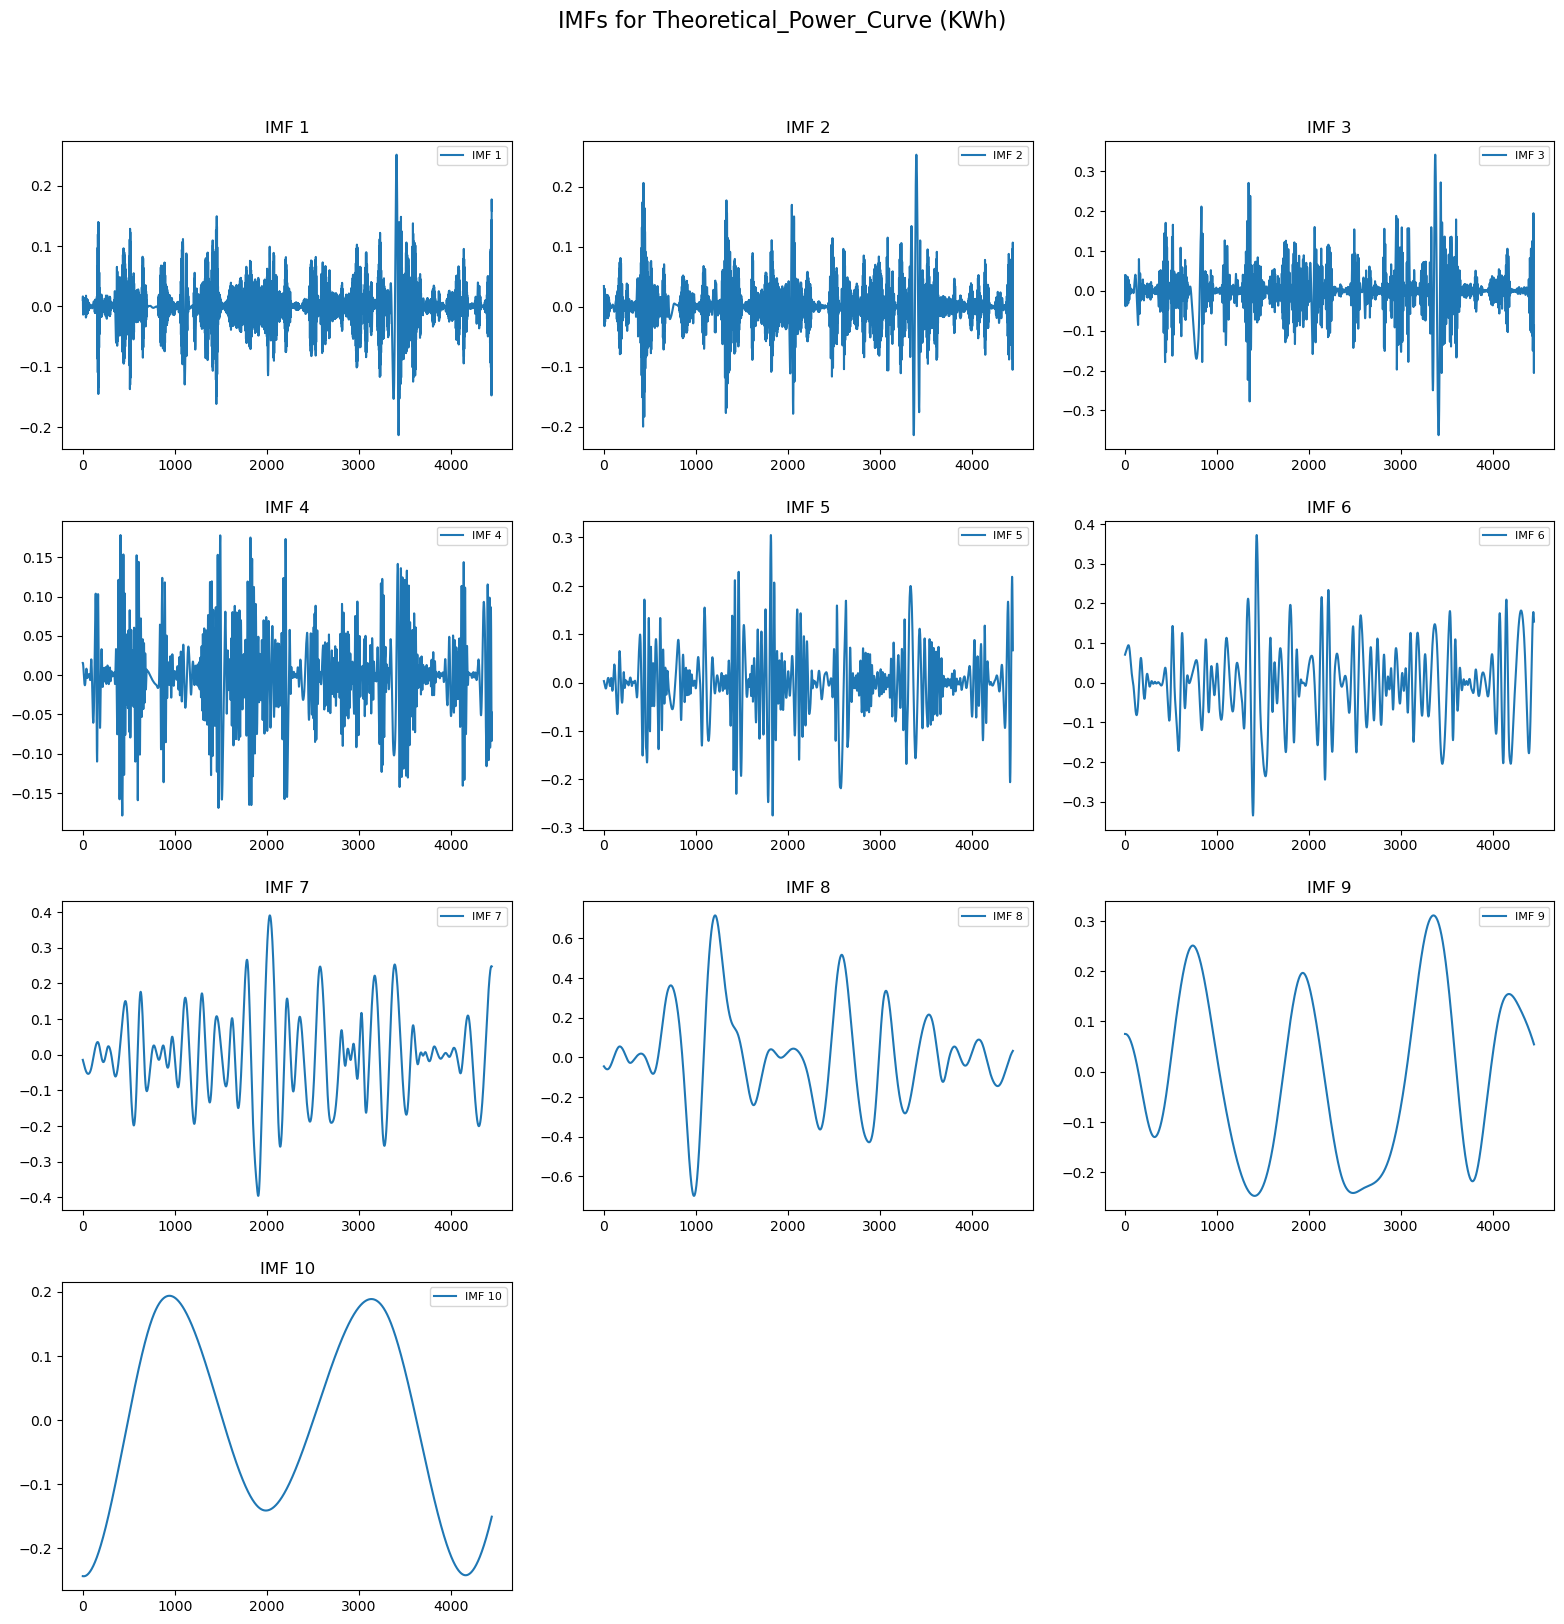

In [64]:
import matplotlib.pyplot as plt
import math
    
# Function to determine optimal grid dimensions
def get_grid_dimensions(n):
    rows = math.ceil(math.sqrt(n))
    cols = math.ceil(n / rows)
    return rows, cols

rows, cols = get_grid_dimensions(num_imfs)

plt.figure(figsize=(16, 4 * rows))  # Adjust figure size based on the number of rows
plt.suptitle(f"IMFs for {col}", fontsize=16, y=1.02)  # Add title for the column
    
for idx in range(num_imfs):
    plt.subplot(rows, cols, idx + 1)
    plt.plot(decomposed_features[col].iloc[:, idx], label=f'IMF {idx + 1}')
    plt.title(f'IMF {idx + 1}')
    plt.legend(loc='upper right', fontsize=8)
    plt.tight_layout(pad=2.0)
    
plt.show()

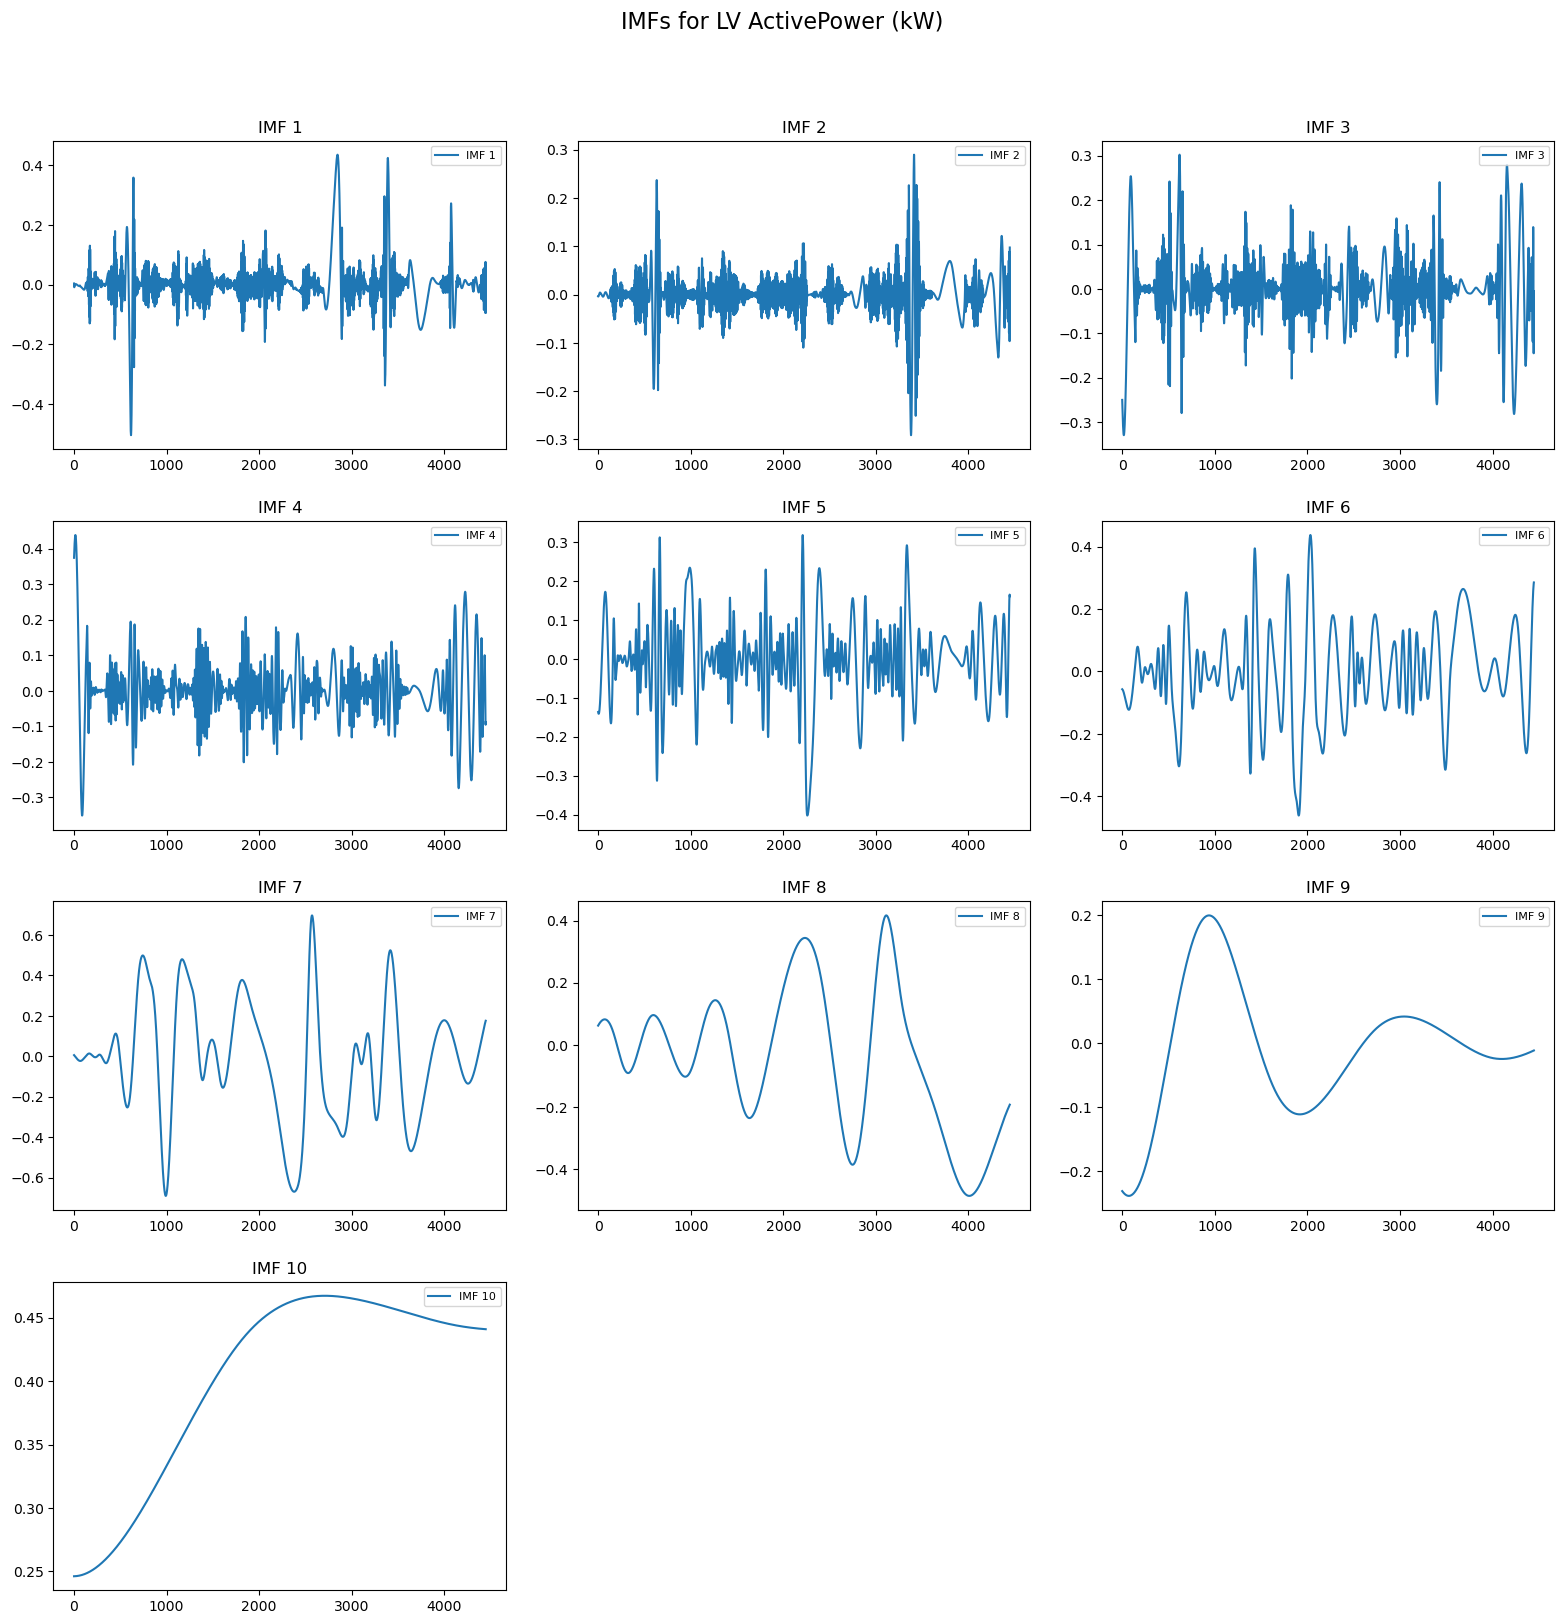

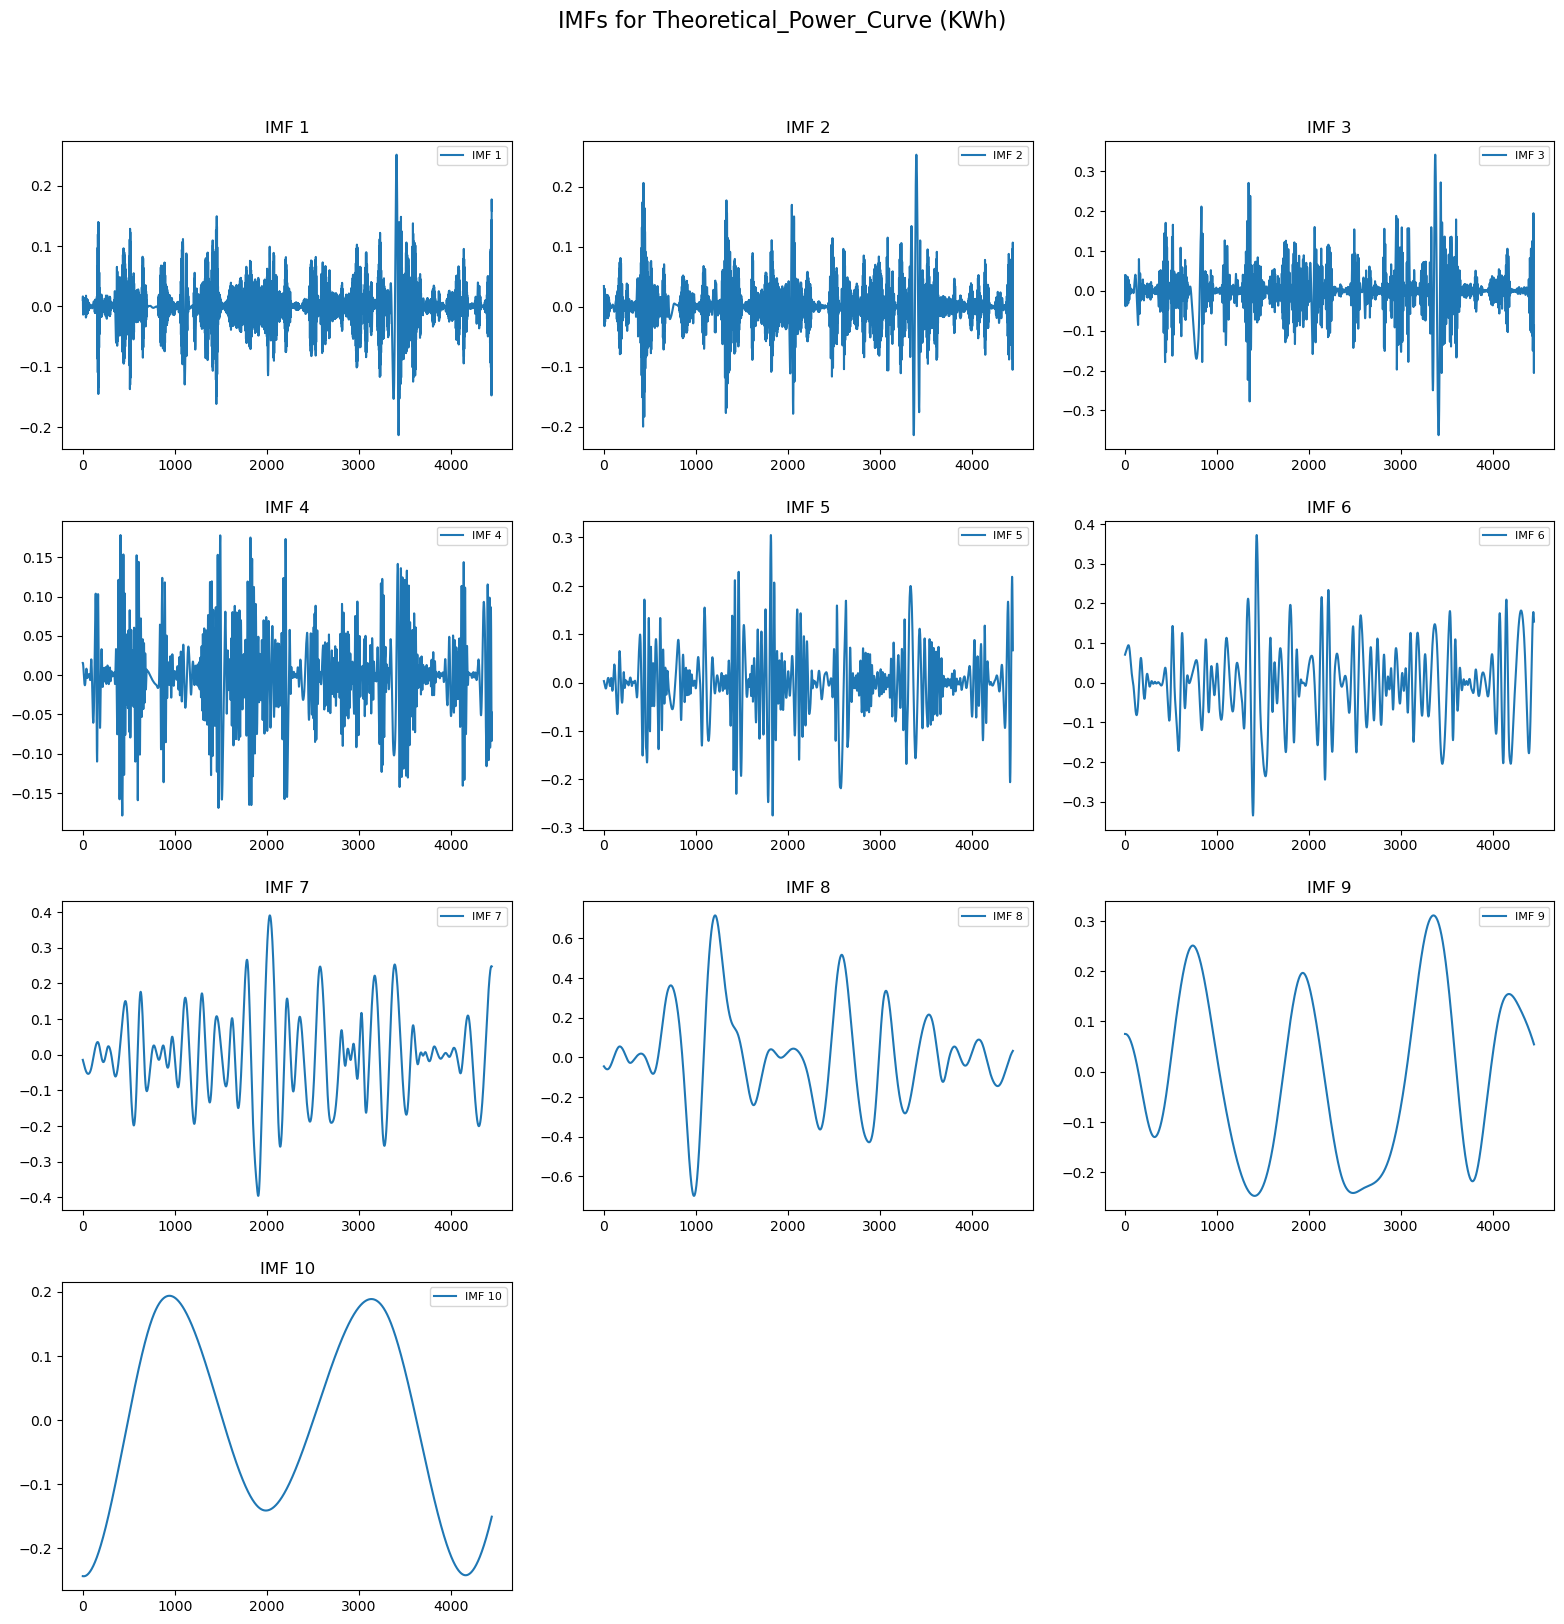

In [65]:
# Function to determine optimal grid dimensions
def get_grid_dimensions(n):
    rows = math.ceil(math.sqrt(n))
    cols = math.ceil(n / rows)
    return rows, cols

for col in decomposed_features:
    num_imfs = decomposed_features[col].shape[1]
    rows, cols = get_grid_dimensions(num_imfs)
    
    plt.figure(figsize=(16, 4 * rows))  # Adjust figure size based on the number of rows
    plt.suptitle(f"IMFs for {col}", fontsize=16, y=1.02)  # Add title for the column
    
    for idx in range(num_imfs):
        plt.subplot(rows, cols, idx + 1)
        plt.plot(decomposed_features[col].iloc[:, idx], label=f'IMF {idx + 1}')
        plt.title(f'IMF {idx + 1}')
        plt.legend(loc='upper right', fontsize=8)
        plt.tight_layout(pad=2.0)
    
    plt.show()


In [66]:
# Create sequences
def create_sequences(features, target, input_length, output_length):
    x, y = [], []
    for j in range(len(features) - input_length - output_length + 1):
        x.append(features.iloc[j:j + input_length].values)
        y.append(target.iloc[j + input_length:j + input_length + output_length].values)
    return np.array(x), np.array(y)

In [67]:
# Prepare lists to store predictions and actual values
pred_train = []
pred_test = []
train_ori = []
test_ori = []

# Model parameters
epoch = 30
batch_size = 64
neuron = 32
lr = 0.001
optimizer_name = 'Adam'
input_length = 6
output_length = 1
data_partition = 0.8

In [68]:
# Evaluate each IMF
for i in range(num_imfs):
    print(f"Processing IMF {i+1}...")

    # Combine IMFs of all features for the current IMF index
    combined_imf = pd.concat([decomposed_features[col].iloc[:, i] for col in decomposed_features], axis=1)
    target_imf = decomposed_target.iloc[:, i]

    # Prepare training and testing data for the current IMF
    train_size = int(len(combined_imf) * data_partition)
    train_features, test_features = combined_imf[:train_size], combined_imf[train_size:]
    train_target, test_target = target_imf[:train_size], target_imf[train_size:]

    # Create sequences
    X_train, y_train = create_sequences(train_features, train_target, input_length, output_length)
    X_test, y_test = create_sequences(test_features, test_target, input_length, output_length)

    if len(X_train) == 0 or len(X_test) == 0:
        continue  # Skip if there is not enough data for this component

    # Reshape data for LSTM
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], -1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)

    # Build and compile a deeper GRU model
    model = Sequential()
    model.add(GRU(units=128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(GRU(units=32, return_sequences=False))
    model.add(Dense(1))
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    model.compile(loss='mae', optimizer=optimizer)


    # Train the model
    model.fit(X_train, y_train, epochs=epoch, batch_size=batch_size, verbose=0)

    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Inverse transform predictions and actual values for the current IMF
    y_pred_train_inv = target_scaler.inverse_transform(y_pred_train)
    y_pred_test_inv = target_scaler.inverse_transform(y_pred_test)
    y_train_inv = target_scaler.inverse_transform(y_train.reshape(-1, 1))
    y_test_inv = target_scaler.inverse_transform(y_test.reshape(-1, 1))

    
    # Debug: Check if scaling is consistent
    print(f"IMF {i+1}: Predicted (scaled): {y_pred_test[:5].flatten()}")
    print(f"IMF {i+1}: Actual (scaled): {y_test[:5].flatten()}")
    print(f"IMF {i+1}: Predicted (inverse): {y_pred_test_inv[:5].flatten()}")
    print(f"IMF {i+1}: Actual (inverse): {y_test_inv[:5].flatten()}")


    # Store predictions and actual values
    pred_train.append(y_pred_train_inv.flatten())
    pred_test.append(y_pred_test_inv.flatten())
    train_ori.append(y_train_inv.flatten())
    test_ori.append(y_test_inv.flatten())


Processing IMF 1...


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
IMF 1: Predicted (scaled): [-0.00373148  0.02850003 -0.01159263  0.02790654 -0.00951438]
IMF 1: Actual (scaled): [-0.00148896  0.01163116  0.0013723   0.01090338  0.00149119]
IMF 1: Predicted (inverse): [-14.524872 101.632996 -42.85533   99.49414  -35.36563 ]
IMF 1: Actual (inverse): [-6.44314152 40.83992911  3.86846345 38.21712465  4.29689611]
Processing IMF 2...


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
IMF 2: Predicted (scaled): [ 0.00908024  0.00347018 -0.00667281 -0.00127635  0.00934878]
IMF 2: Actual (scaled): [ 0.00224152 -0.00369622 -0.00668166 -0.00364442  0.00698386]
IMF 2: Predicted (inverse): [ 31.64677   11.428903 -25.12499   -5.676929  32.61458 ]
IMF 2: Actual (inverse): [  7.000996   -14.39778203 -25.15690807 -14.21109648  24.09170994]
Processing IMF 3...


...

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
IMF 8: Predicted (scaled): [-0.14010966 -0.14094056 -0.14177239 -0.14260522 -0.14343902]
IMF 8: Actual (scaled): [-0.14044483 -0.14126636 -0.14208885 -0.14291233 -0.1437368 ]
IMF 8: Predicted (inverse): [-506.01276 -509.0072  -512.005   -515.0064  -518.01135]
IMF 8: Actual (inverse): [-507.22065704 -510.18131401 -513.14546769 -516.11316239 -519.08444236]
Processing IMF 9...


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
IMF 9: Predicted (scaled): [0.01265283 0.01254215 0.01243139 0.01232056 0.01220965]
IMF 9: Actual (scaled): [0.0087593  0.00866422 0.00856913 0.00847405 0.00837897]
IMF 9: Predicted (inverse): [44.52189  44.123016 43.72387  43.324436 42.924744]
IMF 9: Actual (inverse): [30.49014855 30.1474914  29.80482782 29.46216035 29.11949149]
Processing IMF 10...


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
IMF 10: Predicted (scaled): [0.45180017 0.45177954 0.45175883 0.45173818 0.45171747]
IMF 10: Actual (scaled): [0.45469979 0.4546781  0.4546564  0.4546347  0.454613  ]
IMF 10: Predicted (inverse): [1627.1475 1627.0731 1626.9985 1626.9241 1626.8494]
IMF 10: Actual (inverse): [1637.59730979 1637.51911874 1637.44092538 1637.3627299  1637.2845325 ]


In [69]:
# Convert lists to DataFrames
result_pred_test = pd.DataFrame(pred_test).T  # Transpose to align with actual values
result_pred_train = pd.DataFrame(pred_train).T


# Sum predictions across components
a = result_pred_test.sum(axis=1)
b = result_pred_train.sum(axis=1)


In [70]:
# Prepare actual data
dataset = target.values.reshape(-1, 1)
train_size = int(len(dataset) * data_partition)
train, test = dataset[:train_size], dataset[train_size:]

# Create datasets for training and testing
_, trainY = create_sequences(pd.DataFrame(train), pd.DataFrame(train), input_length, output_length)
_, testY = create_sequences(pd.DataFrame(test), pd.DataFrame(test), input_length, output_length)

# Scale the data
sc_y_total = MinMaxScaler()
y_train_scaled = sc_y_total.fit_transform(trainY.reshape(-1, 1))
y_test_scaled = sc_y_total.transform(testY.reshape(-1, 1))

# Inverse transform actual values
y_test_inv = sc_y_total.inverse_transform(y_test_scaled).flatten()
y_train_inv = sc_y_total.inverse_transform(y_train_scaled).flatten()


In [71]:
# Ensure the lengths match
min_length = min(len(a), len(y_test_inv))
a = a[:min_length]
y_test_series = y_test_inv[:min_length]

# Calculate error metrics
rmse = np.sqrt(mean_squared_error(y_test_series, a))
mae = mean_absolute_error(y_test_series, a)
r2 = r2_score(y_test_series, a)

# Print the results
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}")

RMSE: 86.851
MAE: 59.604
R2: 0.963


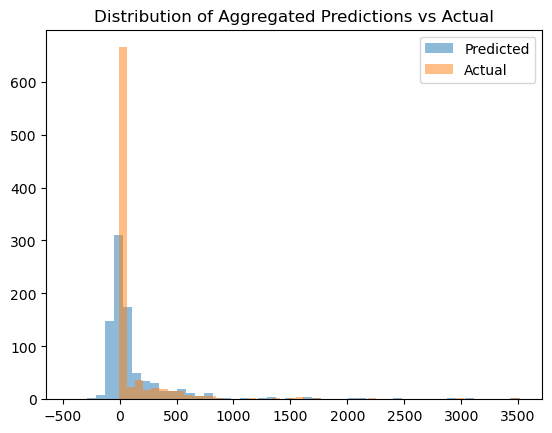

In [72]:
plt.hist(a, bins=50, alpha=0.5, label="Predicted")
plt.hist(y_test_series, bins=50, alpha=0.5, label="Actual")
plt.legend()
plt.title("Distribution of Aggregated Predictions vs Actual")
plt.show()


In [73]:
aggregated_signal = result_pred_test.sum(axis=1)  # Aggregated predictions
print(f"Aggregated Signal Mean: {aggregated_signal.mean()}, Std: {aggregated_signal.std()}")
print(f"Actual Signal Mean: {y_test_series.mean()}, Std: {y_test_series.std()}")


Aggregated Signal Mean: 157.73248291015625, Std: 456.24493408203125
Actual Signal Mean: 160.48870582811148, Std: 453.11992968004654


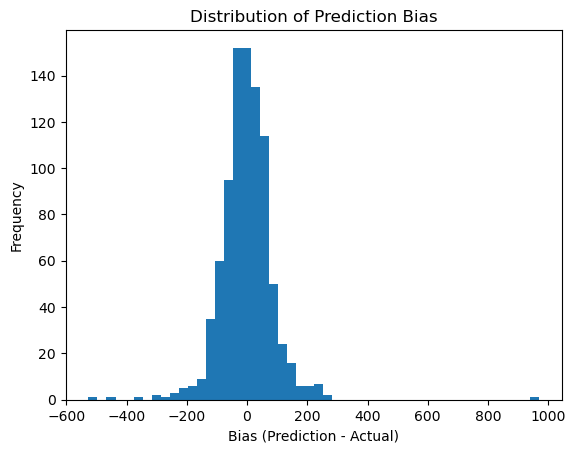

In [74]:
bias = aggregated_signal - y_test_series
plt.hist(bias, bins=50)
plt.title("Distribution of Prediction Bias")
plt.xlabel("Bias (Prediction - Actual)")
plt.ylabel("Frequency")
plt.show()


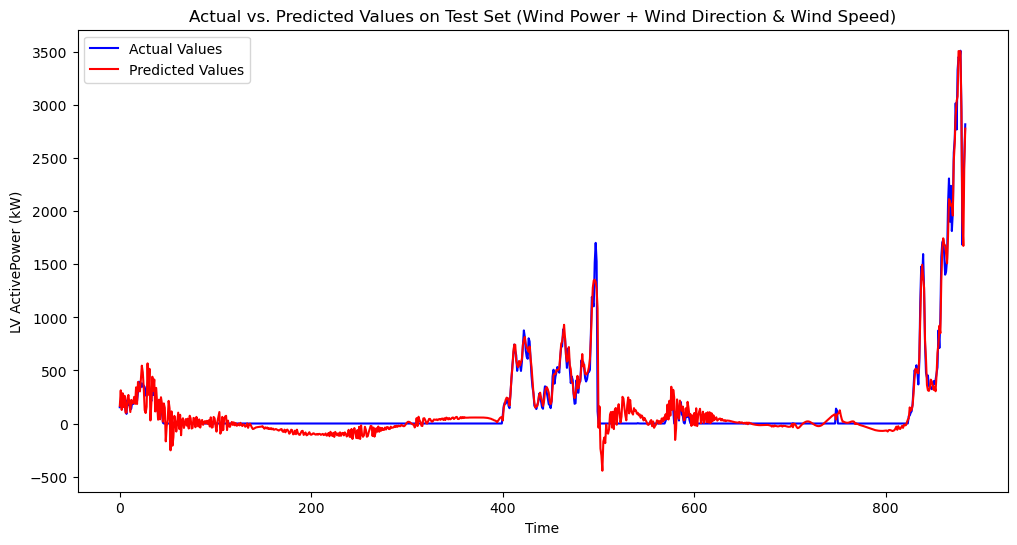

In [75]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_series, label='Actual Values', color='blue')
plt.plot(a.values, label='Predicted Values', color='red')
plt.title('Actual vs. Predicted Values on Test Set (Wind Power + Wind Direction & Wind Speed)')
plt.xlabel('Time')
plt.ylabel('LV ActivePower (kW)')
plt.legend()
plt.show()


In [76]:
# remove any negative values for aggregated signal
aggregated_signal[aggregated_signal < 0] = 0

In [77]:
# Ensure the lengths match
min_length = min(len(aggregated_signal), len(y_test_inv))
aggregated_signal = aggregated_signal[:min_length]
y_test_series = y_test_inv[:min_length]

# Calculate error metrics
rmse = np.sqrt(mean_squared_error(y_test_series, aggregated_signal))
mae = mean_absolute_error(y_test_series, aggregated_signal)
r2 = r2_score(y_test_series, aggregated_signal)

# Print the results
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}")

RMSE: 73.374
MAE: 37.088
R2: 0.974


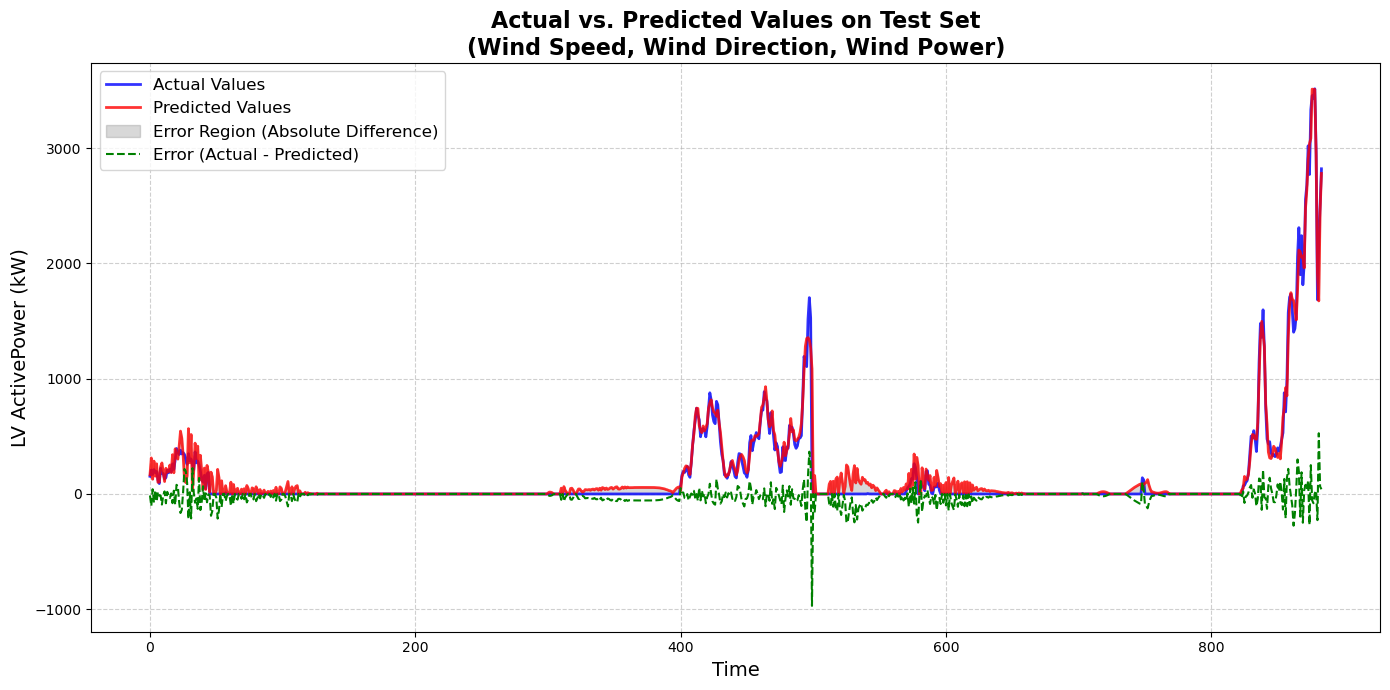

In [78]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the error
error = y_test_series - aggregated_signal

plt.figure(figsize=(14, 7))

# Plot actual values
plt.plot(
    y_test_series, 
    label='Actual Values', 
    color='blue', 
    linewidth=2, 
    alpha=0.8
)

# Plot predicted values
plt.plot(
    aggregated_signal, 
    label='Predicted Values', 
    color='red', 
    linewidth=2, 
    alpha=0.8
)

# Highlight the error region
plt.fill_between(
    range(len(y_test_series)), 
    y_test_series, 
    aggregated_signal, 
    color='gray', 
    alpha=0.3, 
    label='Error Region (Absolute Difference)'
)

# Plot error line
plt.plot(
    error, 
    label='Error (Actual - Predicted)', 
    color='green', 
    linestyle='--', 
    linewidth=1.5
)

# Add grid, labels, and legend
plt.title(
    'Actual vs. Predicted Values on Test Set\n(Wind Speed, Wind Direction, Wind Power)', 
    fontsize=16, 
    fontweight='bold'
)
plt.xlabel('Time', fontsize=14)
plt.ylabel('LV ActivePower (kW)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(visible=True, linestyle='--', alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()
